In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

In [2]:
# ── Load ──
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ── Clean ──
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df = df.drop('customerID', axis=1)

# ── Feature Engineering ──
service_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services']     = (df[service_columns] == 'Yes').sum(axis=1)
df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']
df['avg_monthly_spend']= df['TotalCharges'] / df['tenure'].replace(0, 1)
df['charges_ratio']    = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
df['is_new_customer']  = (df['tenure'] <= 12).astype(int)
df['tenure_group']     = pd.cut(df['tenure'], bins=[-1,12,24,48,60,72],
                                labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])

# ── Encode ──
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)

# ── Split features/label ──
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# ── Train/Test split (stratified) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Features:", X.shape[1], "| Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Features: 39 | Train: 5634 | Test: 1409


In [3]:
# Balance the TRAINING set with SMOTE (test set stays real)
X_train_bal, y_train_bal = SMOTE(random_state=42).fit_resample(X_train, y_train)

# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("After SMOTE:", y_train_bal.value_counts().to_dict())

After SMOTE: {0: 4139, 1: 4139}


In [4]:
# Scaled version of the ORIGINAL (non-SMOTE) training data, for class_weight models
scaler_orig = StandardScaler()
X_train_orig_scaled = scaler_orig.fit_transform(X_train)
X_test_orig_scaled  = scaler_orig.transform(X_test)

ratio = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost's scale_pos_weight

configs = []
# ── SMOTE strategy ──
configs.append(("LogReg (SMOTE)",
    LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train_bal), X_test_scaled))
configs.append(("Random Forest (SMOTE)",
    RandomForestClassifier(random_state=42).fit(X_train_bal, y_train_bal), X_test))
configs.append(("XGBoost (SMOTE)",
    XGBClassifier(random_state=42, eval_metric='logloss').fit(X_train_bal, y_train_bal), X_test))
# ── class_weight strategy ──
configs.append(("LogReg (class_weight)",
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42).fit(X_train_orig_scaled, y_train), X_test_orig_scaled))
configs.append(("Random Forest (class_weight)",
    RandomForestClassifier(class_weight='balanced', random_state=42).fit(X_train, y_train), X_test))
configs.append(("XGBoost (scale_pos_weight)",
    XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss').fit(X_train, y_train), X_test))

rows = []
for name, model, X_eval in configs:
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1]
    rows.append({"Model": name,
                 "Accuracy":  accuracy_score(y_test, preds),
                 "Precision": precision_score(y_test, preds),
                 "Recall":    recall_score(y_test, preds),
                 "F1":        f1_score(y_test, preds),
                 "ROC-AUC":   roc_auc_score(y_test, probs)})

print(pd.DataFrame(rows).round(3))

                          Model  Accuracy  Precision  Recall     F1  ROC-AUC
0                LogReg (SMOTE)     0.783      0.588   0.607  0.597    0.834
1         Random Forest (SMOTE)     0.768      0.560   0.586  0.573    0.818
2               XGBoost (SMOTE)     0.772      0.574   0.551  0.562    0.806
3         LogReg (class_weight)     0.733      0.498   0.786  0.610    0.842
4  Random Forest (class_weight)     0.786      0.632   0.468  0.538    0.822
5    XGBoost (scale_pos_weight)     0.759      0.536   0.679  0.599    0.821


In [5]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators':     [200, 300, 400],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'scale_pos_weight': [1, 2, 2.77, 3.5]   # ← imbalance weighting (tuned)
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, n_iter=30, scoring='roc_auc', cv=5,
    random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)     # ← ORIGINAL imbalanced data (no SMOTE)

best_xgb = search.best_estimator_
print("Best params:", search.best_params_)

# Honest test-set evaluation
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]
print("\nTuned XGBoost — Test Set:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Recall:  ", round(recall_score(y_test, y_pred), 3))
print("F1:      ", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC: ", round(roc_auc_score(y_test, y_prob), 3))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 2.77, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.7}

Tuned XGBoost — Test Set:
Accuracy: 0.742
Recall:   0.81
F1:       0.625
ROC-AUC:  0.846


In [6]:
print("Threshold | Accuracy | Precision | Recall |  F1")
print("-" * 50)
for t in [0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = (y_prob >= t).astype(int)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    print(f"   {t:.2f}   |  {acc:.3f}  |   {prec:.3f}   | {rec:.3f}  | {f1:.3f}")

Threshold | Accuracy | Precision | Recall |  F1
--------------------------------------------------
   0.30   |  0.640  |   0.420   | 0.939  | 0.581
   0.40   |  0.689  |   0.455   | 0.874  | 0.599
   0.45   |  0.718  |   0.482   | 0.840  | 0.612
   0.50   |  0.742  |   0.508   | 0.810  | 0.625
   0.55   |  0.759  |   0.533   | 0.762  | 0.627
   0.60   |  0.776  |   0.562   | 0.698  | 0.623
   0.65   |  0.798  |   0.615   | 0.644  | 0.629
   0.70   |  0.803  |   0.651   | 0.553  | 0.598


In [7]:
param_grid = {
    'n_estimators':     [200, 300, 400, 500, 600],
    'max_depth':        [2, 3, 4, 5, 6],
    'learning_rate':    [0.005, 0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.3],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1, 1.5, 2],
    'scale_pos_weight': [2, 2.77, 3.5]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid, n_iter=50, scoring='roc_auc', cv=5,
    random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

best_xgb2 = search.best_estimator_
print("Best params:", search.best_params_)
y_pred = best_xgb2.predict(X_test)
y_prob = best_xgb2.predict_proba(X_test)[:, 1]
print("\nTest ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("Test Recall: ", round(recall_score(y_test, y_pred), 3))
print("Test F1:     ", round(f1_score(y_test, y_pred), 3))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 2.77, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 1.0}

Test ROC-AUC: 0.847
Test Recall:  0.813
Test F1:      0.626


In [8]:
y_prob2 = best_xgb2.predict_proba(X_test)[:, 1]

print("Threshold | Accuracy | Precision | Recall |  F1")
print("-" * 50)
for t in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    preds = (y_prob2 >= t).astype(int)
    print(f"   {t:.2f}   |  {accuracy_score(y_test, preds):.3f}  |   {precision_score(y_test, preds):.3f}   | {recall_score(y_test, preds):.3f}  | {f1_score(y_test, preds):.3f}")

Threshold | Accuracy | Precision | Recall |  F1
--------------------------------------------------
   0.40   |  0.703  |   0.468   | 0.866  | 0.607
   0.45   |  0.726  |   0.491   | 0.834  | 0.618
   0.50   |  0.742  |   0.509   | 0.813  | 0.626
   0.55   |  0.754  |   0.525   | 0.773  | 0.626
   0.60   |  0.774  |   0.557   | 0.714  | 0.626
   0.65   |  0.793  |   0.600   | 0.655  | 0.627
   0.70   |  0.803  |   0.642   | 0.586  | 0.613


In [9]:
# ===== FINAL MODEL: Tuned XGBoost, threshold 0.55 =====
final_model = best_xgb2
final_threshold = 0.55

y_prob_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_prob_final >= final_threshold).astype(int)

print("FINAL MODEL — Tuned XGBoost (threshold = 0.55)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_final):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_final):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Stay','Churn']))

FINAL MODEL — Tuned XGBoost (threshold = 0.55)

Accuracy:  0.754
Precision: 0.525
Recall:    0.773
F1 Score:  0.626
ROC-AUC:   0.847

Confusion Matrix:
[[774 261]
 [ 85 289]]

Classification Report:
              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



In [10]:
!pip install shap

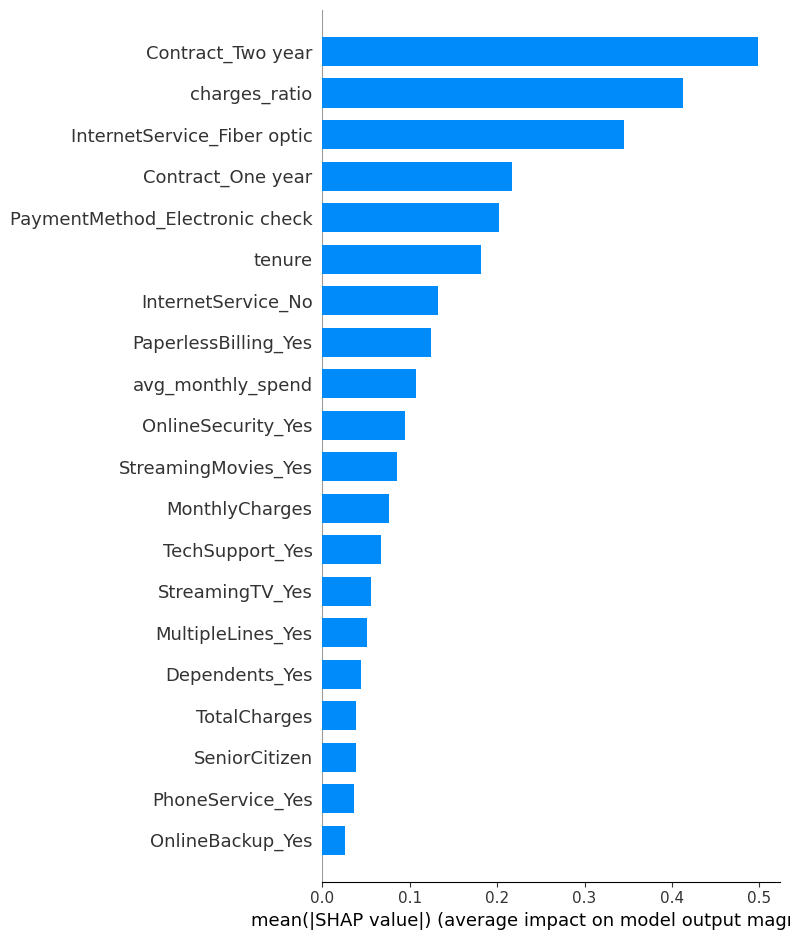

In [11]:
import shap

# TreeExplainer = the fast SHAP method for tree models like XGBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# GLOBAL view: top churn drivers across all customers (bar chart)
shap.summary_plot(shap_values, X_test, plot_type="bar")

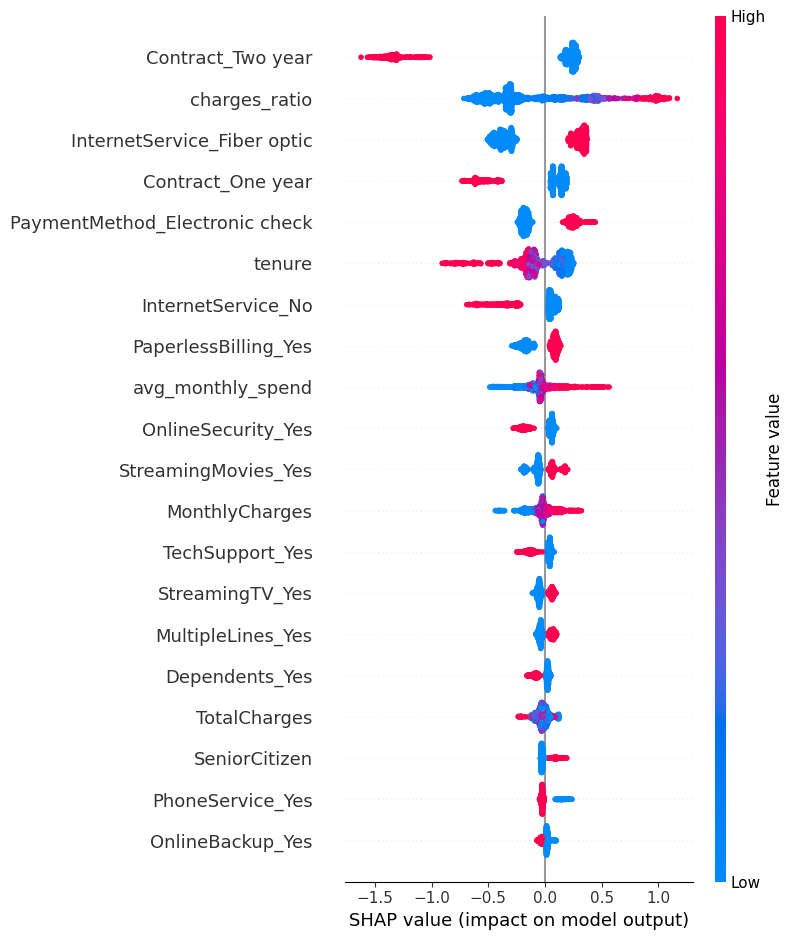

In [12]:
shap.summary_plot(shap_values, X_test)

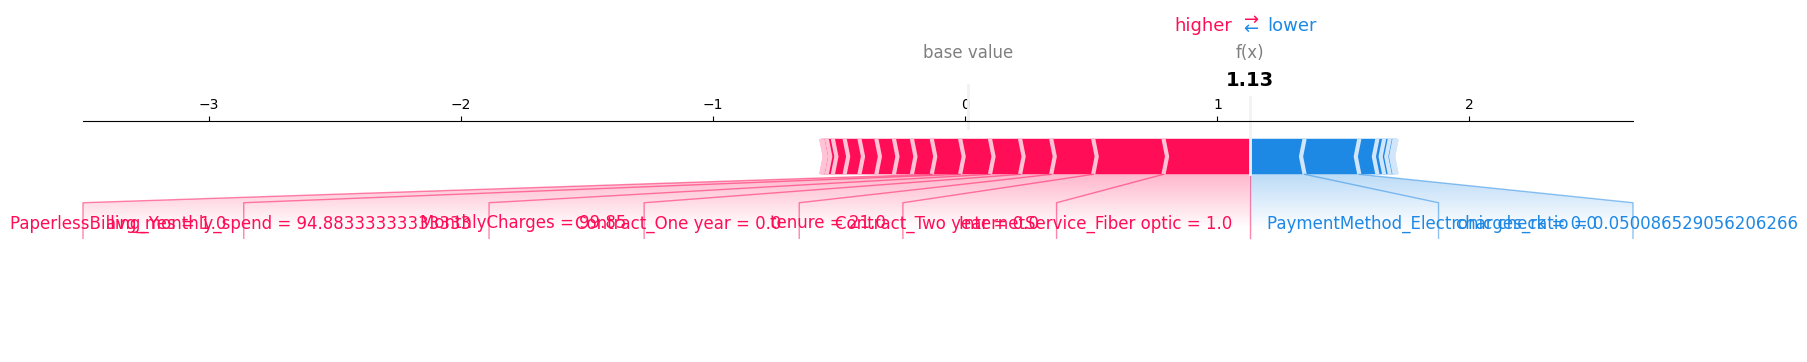

In [13]:
# Explain a single customer's prediction
i = 5  # pick any test customer (try different numbers)
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i],
    matplotlib=True
)

In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

# FINAL MODEL — fixed hyperparameters (from tuning) = reproducible every run
final_model = XGBClassifier(
    n_estimators=300, max_depth=2, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.6, min_child_weight=7,
    gamma=0.1, reg_alpha=0.5, reg_lambda=1.5,
    scale_pos_weight=2, random_state=42, eval_metric='logloss'
)
final_model.fit(X_train, y_train)

# Evaluate at threshold 0.55
final_threshold = 0.55
y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= final_threshold).astype(int)

print("FINAL MODEL — Tuned XGBoost (fixed params, threshold 0.55)\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

FINAL MODEL — Tuned XGBoost (fixed params, threshold 0.55)

Accuracy:  0.795
Precision: 0.599
Recall:    0.687
F1 Score:  0.640
ROC-AUC:   0.848

Confusion Matrix:
[[863 172]
 [117 257]]


In [16]:
import joblib
joblib.dump(final_model, 'churn_model.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("Saved!")

Saved!
